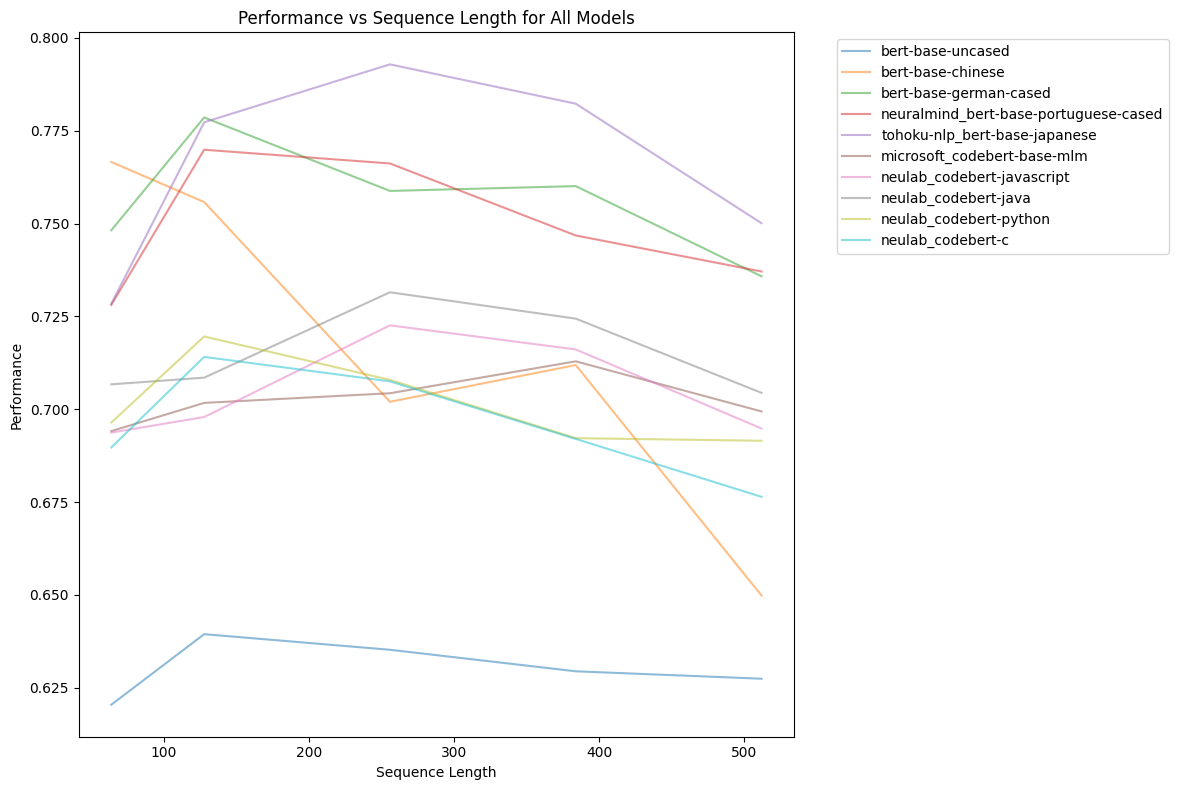

In [1]:
import matplotlib.pyplot as plt
import json

sequence_lengths = [64, 128, 256, 384, 512]

plt.figure(figsize=(12, 8))

# 모델 이름 리스트
models = [
    'bert-base-uncased',
    'bert-base-chinese',
    'bert-base-german-cased',
    'neuralmind_bert-base-portuguese-cased',
    'tohoku-nlp_bert-base-japanese',
    'microsoft_codebert-base-mlm',
    'neulab_codebert-javascript',
    'neulab_codebert-java',
    'neulab_codebert-python',
    'neulab_codebert-c'
]

for model_name in models:
    performance_file = f"{model_name}_result/performance_results.json"
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    performances = [performance_data[str(length)] for length in sequence_lengths]
    plt.plot(sequence_lengths, performances, label=model_name, alpha=0.5)

plt.xlabel('Sequence Length')
plt.ylabel('Performance')
plt.title('Performance vs Sequence Length for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

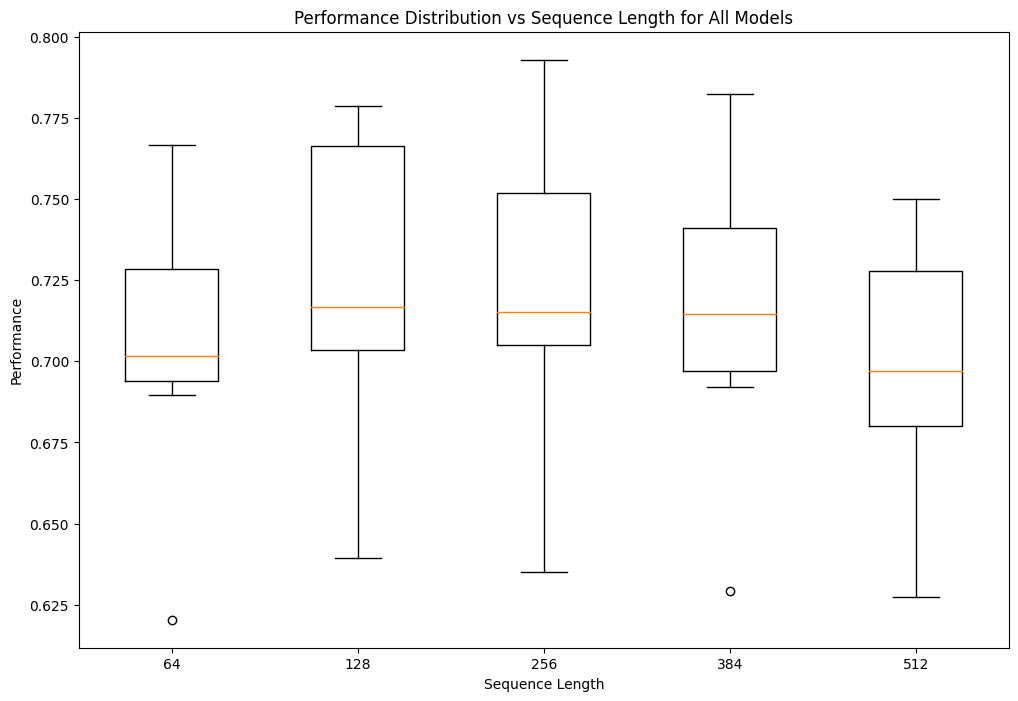

In [2]:
import matplotlib.pyplot as plt
import json

sequence_lengths = [64, 128, 256, 384, 512]
all_performances = {length: [] for length in sequence_lengths}

for model_name in models:
    performance_file = f"{model_name}_result/performance_results.json"
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    for length in sequence_lengths:
        all_performances[length].append(performance_data[str(length)])

plt.figure(figsize=(12, 8))
plt.boxplot([all_performances[length] for length in sequence_lengths], labels=sequence_lengths)
plt.xlabel('Sequence Length')
plt.ylabel('Performance')
plt.title('Performance Distribution vs Sequence Length for All Models')
plt.show()

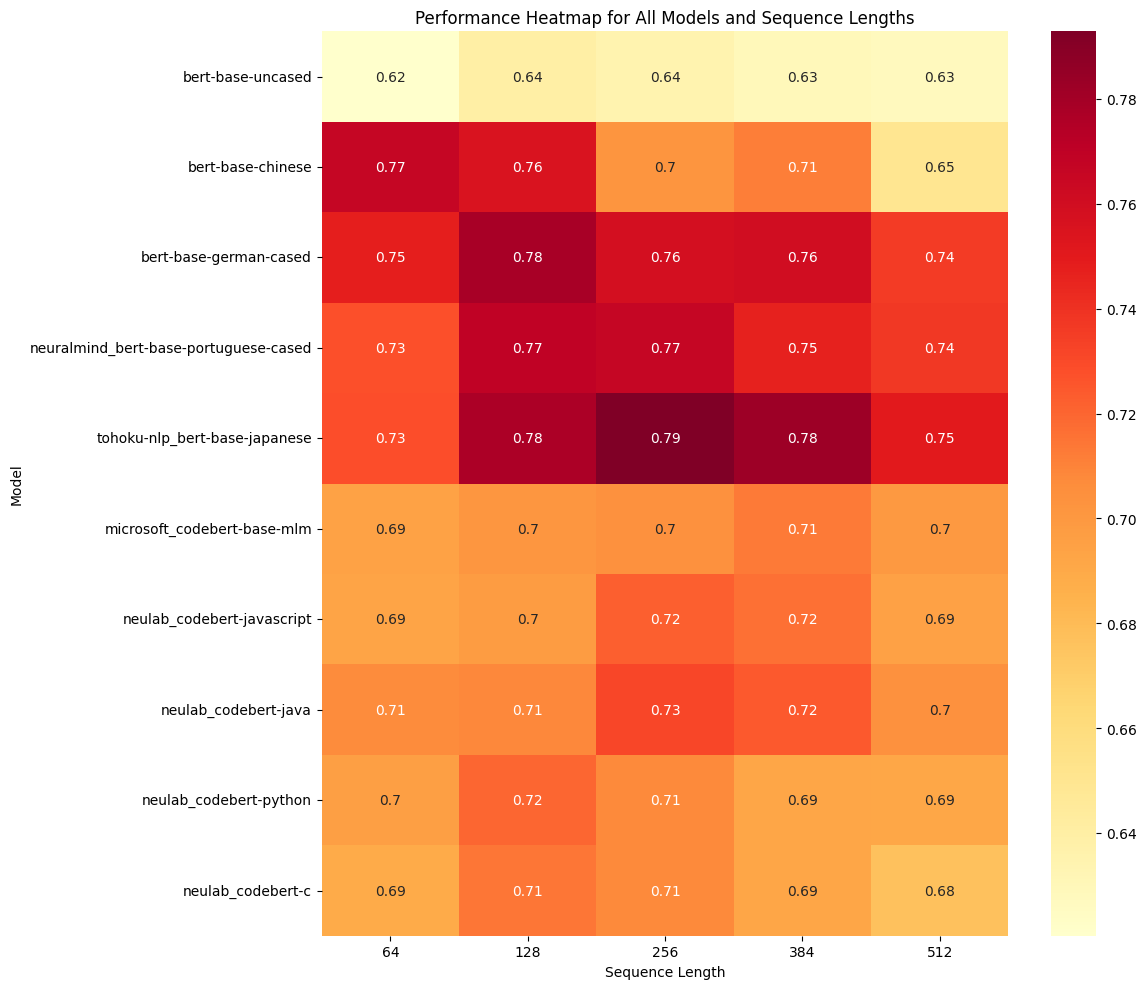

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

sequence_lengths = [64, 128, 256, 384, 512]
performance_matrix = []

for model_name in models:
    performance_file = f"{model_name}_result/performance_results.json"
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    performances = [performance_data[str(length)] for length in sequence_lengths]
    performance_matrix.append(performances)

plt.figure(figsize=(12, 10))
sns.heatmap(performance_matrix, xticklabels=sequence_lengths, yticklabels=models, cmap='YlOrRd', annot=True)
plt.xlabel('Sequence Length')
plt.ylabel('Model')
plt.title('Performance Heatmap for All Models and Sequence Lengths')
plt.tight_layout()
plt.show()

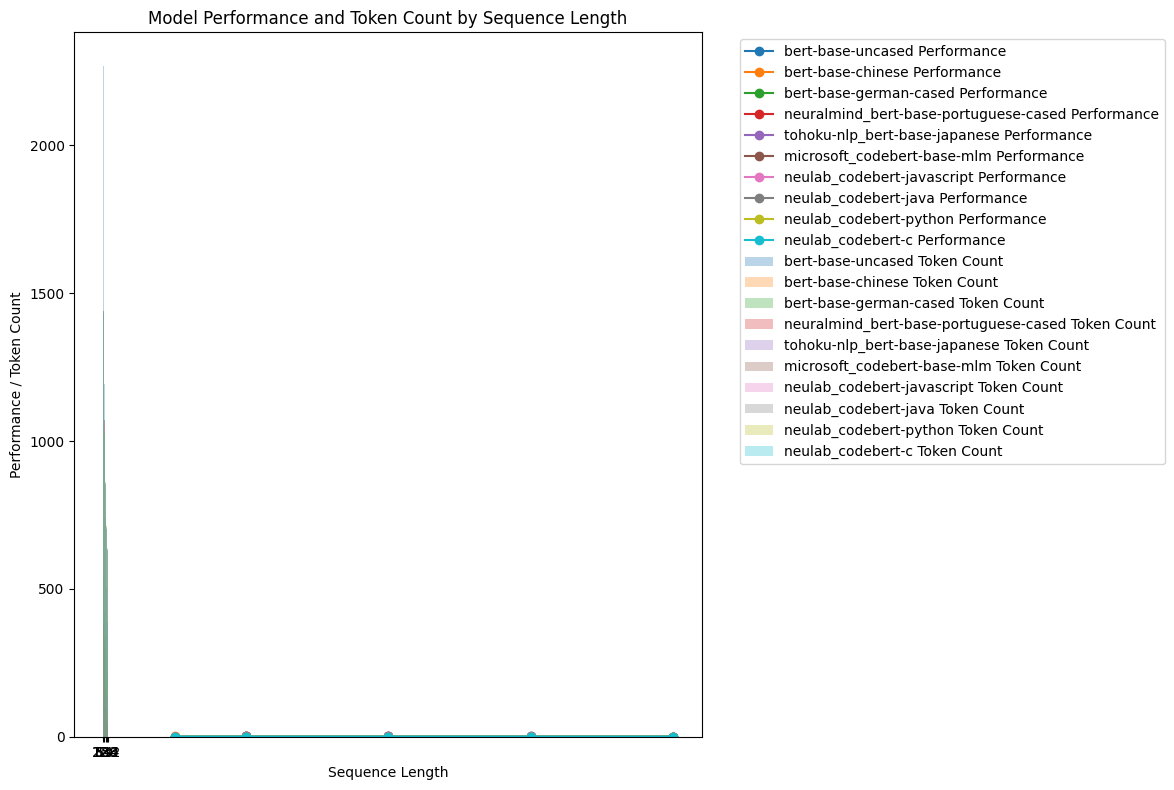

In [4]:
import os
import json
import matplotlib.pyplot as plt

# 모델 이름 리스트
models = [
    'bert-base-uncased',
    'bert-base-chinese',
    'bert-base-german-cased',
    'neuralmind_bert-base-portuguese-cased',
    'tohoku-nlp_bert-base-japanese',
    'microsoft_codebert-base-mlm',
    'neulab_codebert-javascript',
    'neulab_codebert-java',
    'neulab_codebert-python',
    'neulab_codebert-c'
]

# 관심 있는 시퀀스 길이 범위
sequence_lengths = [64, 128, 256, 384, 512]

# 그래프 설정
plt.figure(figsize=(12, 8))

for model_name in models:
    model_folder = f"{model_name}_result"
    
    # token_counts_original.txt 파일 읽기
    token_counts_file = os.path.join(model_folder, "token_counts_original.txt")
    sequence_counts = {}
    
    with open(token_counts_file, 'r') as f:
        for line in f:
            length, count = map(int, line.strip().split(': '))
            if length in sequence_lengths:
                sequence_counts[length] = count
    
    # 시퀀스 길이에 맞는 데이터 수 리스트 생성
    sequence_count_list = [sequence_counts[length] for length in sequence_lengths]
    
    # 성능 결과 파일 읽기
    performance_file = os.path.join(model_folder, "performance_results.json")
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    # 시퀀스 길이에 맞는 성능 리스트 생성
    model_performance = [performance_data[str(length)] for length in sequence_lengths]
    
    # 그래프 그리기: 데이터 수와 성능을 비교
    plt.plot(sequence_lengths, model_performance, label=f"{model_name} Performance", linestyle='-', marker='o')
    plt.bar([str(length) for length in sequence_lengths], sequence_count_list, alpha=0.3, label=f"{model_name} Token Count")

plt.xlabel('Sequence Length')
plt.ylabel('Performance / Token Count')
plt.title('Model Performance and Token Count by Sequence Length')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import json
import os

# 모델 이름 리스트
models = [
    'bert-base-uncased',
    'bert-base-chinese',
    'bert-base-german-cased',
    'neuralmind_bert-base-portuguese-cased',
    'tohoku-nlp_bert-base-japanese',
    'microsoft_codebert-base-mlm',
    'neulab_codebert-javascript',
    'neulab_codebert-java',
    'neulab_codebert-python',
    'neulab_codebert-c'
]

# 관심 있는 시퀀스 길이 범위
sequence_lengths = [64, 128, 256, 384, 512]

plt.figure(figsize=(15, 10))

for model_name in models:
    model_folder = f"{model_name}_result"
    
    # token_counts_original.txt 파일 읽기
    token_counts_file = os.path.join(model_folder, "token_counts_original.txt")
    sequence_counts = {}
    
    with open(token_counts_file, 'r') as f:
        for line in f:
            length, count = map(int, line.strip().split(': '))
            sequence_counts[length] = count
    
    # performance_results.json 파일 읽기
    performance_file = os.path.join(model_folder, "performance_results.json")
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    # 데이터 준비
    lengths = list(sequence_counts.keys())
    counts = list(sequence_counts.values())
    performances = [performance_data[str(length)] for length in lengths]

    # 첫 번째 y축: 토큰 카운트
    plt.plot(lengths, counts, label=f"{model_name} (Count)", alpha=0.5)

    # 두 번째 y축: 성능
    ax2 = plt.twinx()
    ax2.plot(lengths, performances, label=f"{model_name} (Performance)", linestyle='--')

plt.xlabel('Sequence Length')
plt.ylabel('Token Count')
ax2.set_ylabel('Performance')
plt.title('Token Count and Performance vs Sequence Length')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 구간별 평균 성능 계산 및 출력
intervals = [(1, 64), (65, 128), (129, 256), (257, 384), (385, 512)]
for model_name in models:
    model_folder = f"{model_name}_result"
    performance_file = os.path.join(model_folder, "performance_results.json")
    with open(performance_file, 'r') as f:
        performance_data = json.load(f)
    
    print(f"\n{model_name} Average Performance:")
    for start, end in intervals:
        avg_performance = sum(performance_data[str(i)] for i in range(start, end+1)) / (end - start + 1)
        print(f"{start}-{end}: {avg_performance:.4f}")

KeyError: '1'

<Figure size 1500x1000 with 0 Axes>